In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scripts.lattice import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *

import seaborn as sns
color_list = sns.color_palette('colorblind') + sns.color_palette("Set2") + sns.color_palette("Set3")

dim = 3
save_dir = f'data/{dim}d/rpa'

Starting serial run at: 2026-06-08 18:33:55.863824


SCBA: nk=200^2, niw=128, T=0.10, mu=0.0000, v=0.100
Converged at step 7 with diff = 1.922e-11, mu = -3.739e-02


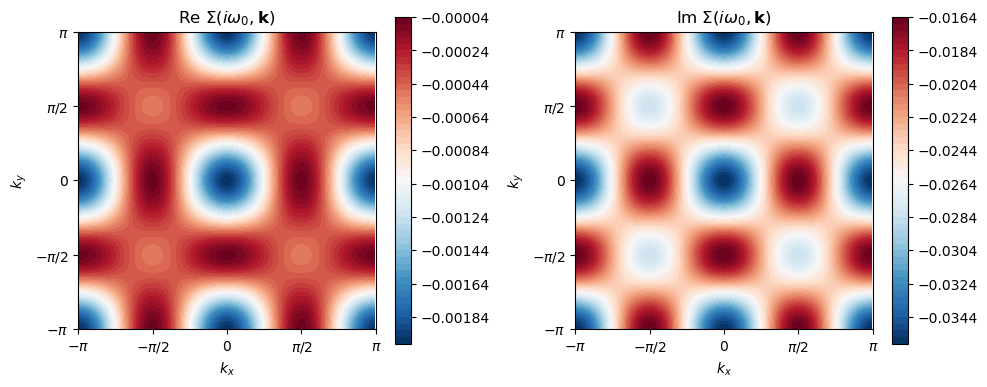

In [21]:
from scripts.scba import *

lat = LATTICE(dim=2)
nk = 200
lat.get_bz(nk, ibz=True)
lat.get_e_k()

kx = np.linspace(-np.pi, np.pi, nk, endpoint=False)
ky = np.linspace(-np.pi, np.pi, nk, endpoint=False)
kx, ky = np.meshgrid(kx, ky, indexing='ij')

niw = 128
beta = 1/0.1
n = 0.85
scba = SCBA(lat, niw, nk)
scba.run(0.1, beta, n, ibz=True)

S_iwk = lat.unfold_f_iwk(scba.S_iwk)

S_grid = S_iwk.reshape(niw,nk,nk)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

c0 = axes[0].contourf(kx, ky, S_grid[0].real, levels=50, cmap='RdBu_r')
plt.colorbar(c0, ax=axes[0])
axes[0].set_title(r'Re $\Sigma(i\omega_0, \mathbf{k})$')

c1 = axes[1].contourf(kx, ky, S_grid[0].imag, levels=50, cmap='RdBu_r')
plt.colorbar(c1, ax=axes[1])
axes[1].set_title(r'Im $\Sigma(i\omega_0, \mathbf{k})$')

for ax in axes:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

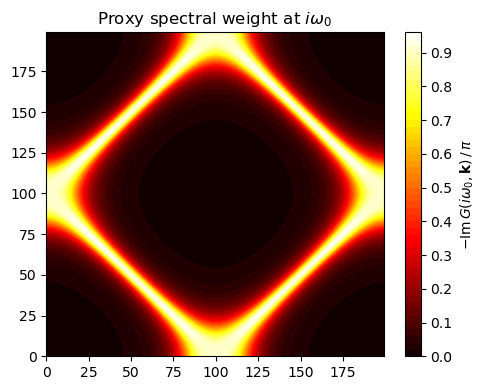

In [22]:
# G(iω_n, k) = 1 / (iω_n - ε_k - Σ(iω_n, k))
# At n=0 (first positive Matsubara freq): ω_0 = π/β

omega_0 = np.pi / beta  # = π · T

# ε_k on full BZ, shape (nk, nk)
e_k_full = lat.unfold_f_k(lat.e_k)   # adjust to your API

# Σ(iω_0, k) — already computed above
# S_k_n0 shape (nk, nk), complex

G_k_n0 = 1.0 / (1j * omega_0 - e_k_full - S_iwk[0])

# Proxy spectral weight: -Im G(iω_0, k) / π
A_proxy = -G_k_n0.imag / np.pi

plt.figure(figsize=(5, 4))
plt.contourf(A_proxy.reshape(nk,nk), levels=50, cmap='hot')
plt.colorbar(label=r'$-\mathrm{Im}\, G(i\omega_0,\mathbf{k})\,/\,\pi$')
plt.title(r'Proxy spectral weight at $i\omega_0$')
plt.tight_layout()
plt.show()

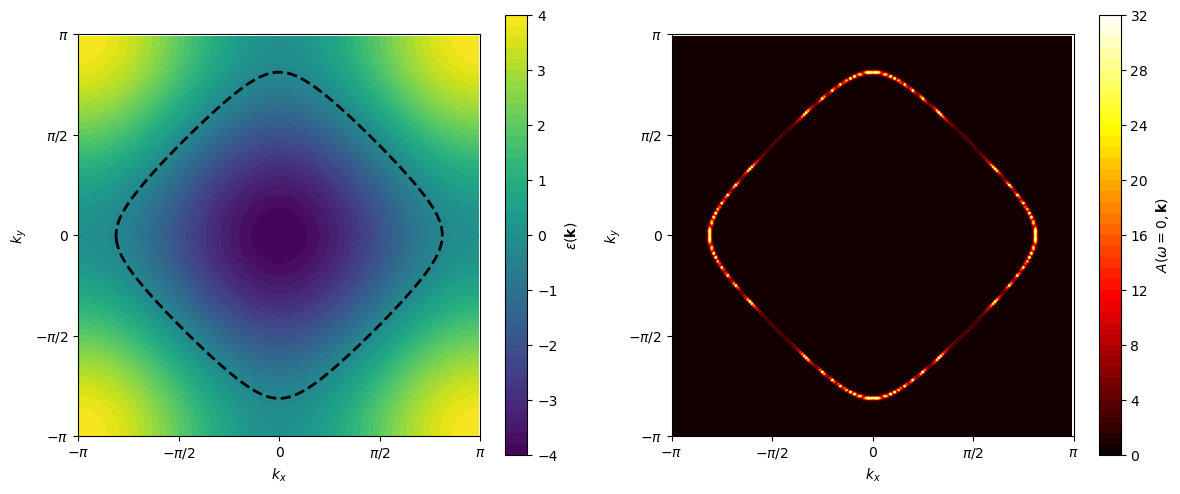

In [6]:
lat = LATTICE(dim=2)
nk = 200

lat.get_bz(nk, ibz=False)
lat.get_e_k()

kx = lat.k_vecs[:,0].reshape(nk,nk)
ky = lat.k_vecs[:,1].reshape(nk,nk)
e_k = lat.e_k.reshape(nk,nk)

kx -= np.pi
ky -= np.pi
e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

mu = get_mu(e_k=lat.e_k, n_goal=0.9, beta=1/1)
eta = 0.01
A_k0 = (1/np.pi) * eta / (eta**2 + (e_k - mu)**2)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

cf = axs[0].contourf(kx, ky, e_k, levels=50)
plt.colorbar(cf, ax=axs[0], label=r'$\varepsilon(\mathbf{k})$')
axs[0].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=2)

cf = axs[1].contourf(kx, ky, A_k0, levels=50, cmap='hot')
plt.colorbar(cf, ax=axs[1], label=r'$A(\omega=0, \mathbf{k})$')

for ax in axs:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

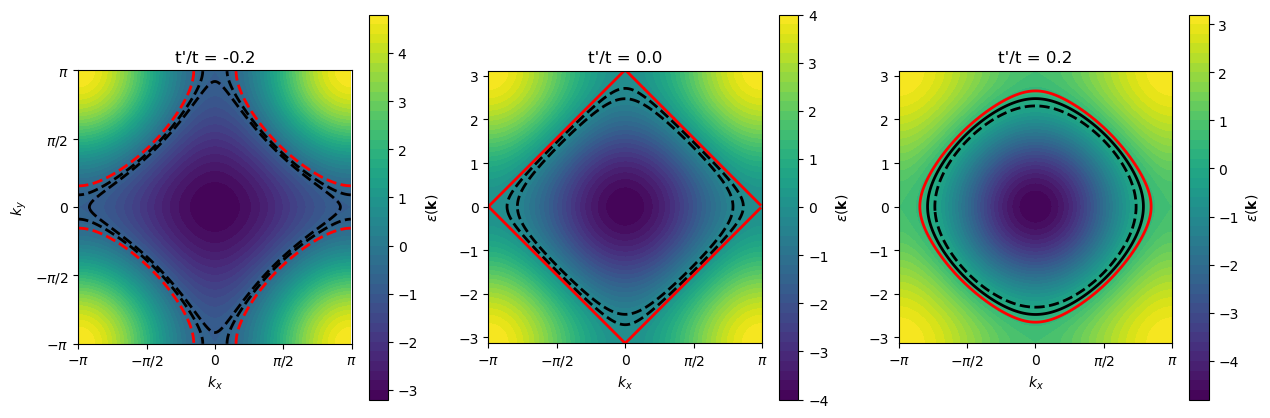

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

tp_list = [-0.2, 0., 0.2]
for i, tp in enumerate([-0.2, 0., 0.2]):

    lat = LATTICE(dim=2, tp=tp)
    nk = 200

    lat.get_bz(nk, ibz=False)
    lat.get_e_k()

    kx = lat.k_vecs[:,0].reshape(nk,nk)
    ky = lat.k_vecs[:,1].reshape(nk,nk)
    e_k = lat.e_k.reshape(nk,nk)

    kx -= np.pi
    ky -= np.pi
    e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

    T = 0.01
    n_list = [0.8, 0.9, 1.]
    mu_list = [get_mu(e_k=lat.e_k, n_goal=n, beta=1/T) for n in n_list]

    cf = axs[i].contourf(kx, ky, e_k, levels=50)
    plt.colorbar(cf, ax=axs[i], label=r'$\varepsilon(\mathbf{k})$')
    axs[i].contour(kx, ky, e_k, levels=mu_list[:-1], colors='black', linewidths=2)
    axs[i].contour(kx, ky, e_k, levels=[mu_list[-1]], colors='red', linewidths=2)

    axs[i].set_title(f"t'/t = {tp}")

    axs[i].set_xlabel(r'$k_x$')
    axs[i].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    axs[i].set_aspect('equal')

axs[0].set_ylabel(r'$k_y$')
axs[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

plt.show()

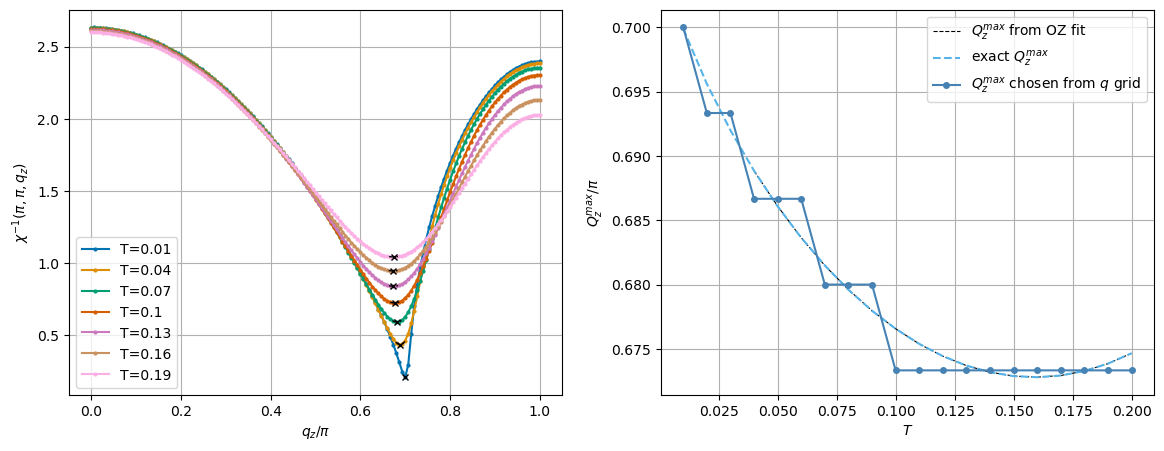

In [29]:
n = 0.745
T_list = np.linspace(0.01, 0.2, 20)
U = 3

nk = 300
lat = LATTICE()
initialize_bz(lat, nk, refine=True, ibz=True)

inputs = [{'lat': lat, 'q_path': ([1,1,0],[1,1,1]), 'method': 'lindhard', 'get_xi': True, 'xi_range': [0,0,1e-2],'verbose': False, 'save_invchigrid': True, 'always_fit_qmin': True, 'par': {'U': U, 'n': n, 'T': T}} for T in T_list]

results_list = run_parallel(run_rpa, inputs, workers=5)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
    fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z/\pi$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q_z^{max}/\pi$')

q_path = ([1,1,0],[1,1,1])
q_grid, _ = get_grid_from_path(q_path, lat.k_vecs)
qz_grid = q_grid[:,-1]
Qz = []
Qz_ref = []
Qz_fit = []
for i, data in enumerate(results_list):
    
    Qz.append(qz_grid[np.argmin(data['invchi_grid'])])
    Qz_ref.append(data['Q'][-1])
    Qz_fit.append(data['Q_fitted'][-1])
    plot_every = 3
    if i%plot_every == 0:
        ax[0].plot(qz_grid, data['invchi_grid'], 'o-', markersize=2, label=f'T={T_list[i]:.4g}', color=color_list[i//plot_every])

        qz_grid_fitted = np.linspace(Qz_ref[-1]-data['xi_range'][-1], Qz_ref[-1]+data['xi_range'][-1], data['xi_pts'])
        OZ_curve = [1/OZ(qz, *data['OZ_fit']) for qz in qz_grid_fitted]
        ax[0].plot(qz_grid_fitted, OZ_curve, '--', color='black', linewidth=1)
        ax[0].plot(Qz_ref[-1], data['invchi'], 'x', markersize=4, color='black')

ax[1].plot(T_list, Qz_fit, '--', color='black', linewidth=0.8, label='$Q_z^{max}$ from OZ fit')
ax[1].plot(T_list, Qz_ref, '--', color=color_list[9], label='exact $Q_z^{max}$')
ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue', label='$Q_z^{max}$ chosen from $q$ grid')

for a in ax:
    a.grid()
    a.legend()
plt.show()

Starting serial run at: 2026-06-08 02:00:42.475104
Starting serial run at: 2026-06-08 02:00:42.479608
Starting serial run at: 2026-06-08 02:00:42.481475
Starting serial run at: 2026-06-08 02:00:42.600293
Starting serial run at: 2026-06-08 02:00:42.642867
/home/ctort/Desktop/dmft/code/scripts/obs.py:532: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:532: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:532: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:532: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit

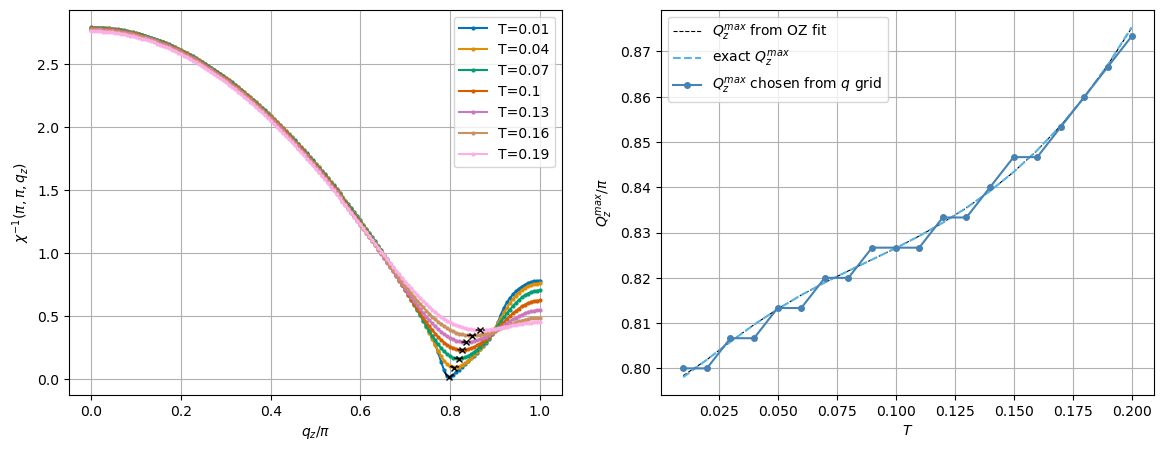

In [31]:
n = 0.85
T_list = np.linspace(0.01, 0.2, 20)
U = 3

nk = 300
lat = LATTICE(tp=0.1)
initialize_bz(lat, nk, refine=True, ibz=True)

inputs = [{'lat': lat, 'q_path': ([1,1,0],[1,1,1]), 'method': 'lindhard', 'get_xi': True, 'xi_range': [0,0,1e-2],'verbose': False, 'save_invchigrid': True, 'always_fit_qmin': True, 'par': {'U': U, 'n': n, 'T': T}} for T in T_list]

results_list = run_parallel(run_rpa, inputs, workers=5)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
    fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z/\pi$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q_z^{max}/\pi$')

q_path = ([1,1,0],[1,1,1])
q_grid, _ = get_grid_from_path(q_path, lat.k_vecs)
qz_grid = q_grid[:,-1]
Qz = []
Qz_ref = []
Qz_fit = []
for i, data in enumerate(results_list):
    
    Qz.append(qz_grid[np.argmin(data['invchi_grid'])])
    Qz_ref.append(data['Q'][-1])
    Qz_fit.append(data['Q_fitted'][-1])
    plot_every = 3
    if i%plot_every == 0:
        ax[0].plot(qz_grid, data['invchi_grid'], 'o-', markersize=2, label=f'T={T_list[i]:.4g}', color=color_list[i//plot_every])

        qz_grid_fitted = np.linspace(Qz_ref[-1]-data['xi_range'][-1], Qz_ref[-1]+data['xi_range'][-1], data['xi_pts'])
        OZ_curve = [1/OZ(qz, *data['OZ_fit']) for qz in qz_grid_fitted]
        ax[0].plot(qz_grid_fitted, OZ_curve, '--', color='black', linewidth=1)
        ax[0].plot(Qz_ref[-1], data['invchi'], 'x', markersize=4, color='black')

ax[1].plot(T_list, Qz_fit, '--', color='black', linewidth=0.8, label='$Q_z^{max}$ from OZ fit')
ax[1].plot(T_list, Qz_ref, '--', color=color_list[9], label='exact $Q_z^{max}$')
ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue', label='$Q_z^{max}$ chosen from $q$ grid')

for a in ax:
    a.grid()
    a.legend()
plt.show()

Starting serial run at: 2026-06-08 04:09:23.114553
Starting serial run at: 2026-06-08 04:09:23.207103
Starting serial run at: 2026-06-08 04:09:23.233642
Starting serial run at: 2026-06-08 04:09:23.243799
Starting serial run at: 2026-06-08 04:09:23.261813
/home/ctort/Desktop/dmft/code/scripts/obs.py:532: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:532: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:532: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:532: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit

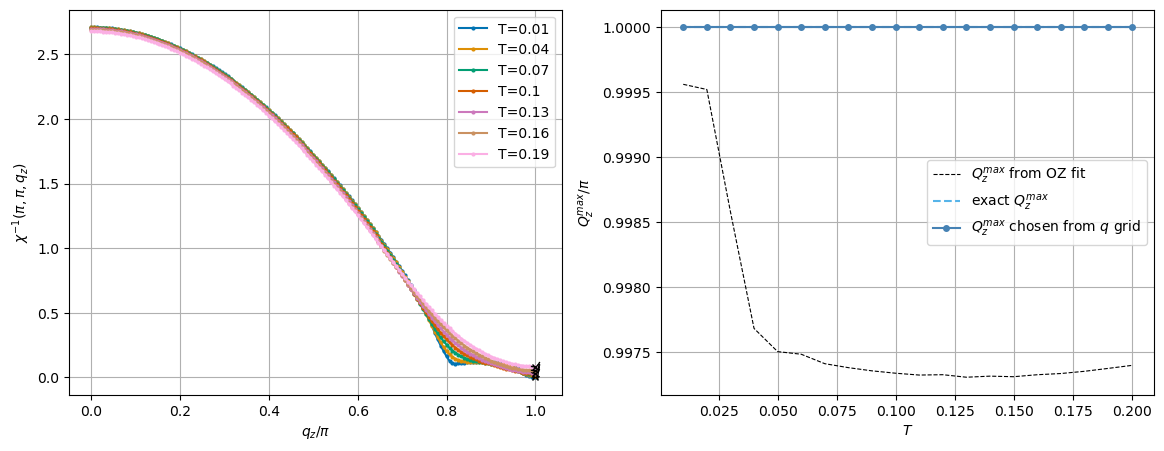

In [3]:
n = 0.8849
T_list = np.linspace(0.01, 0.2, 20)
U = 3

nk = 300
lat = LATTICE(tp=0.2)
initialize_bz(lat, nk, refine=True, ibz=True)

inputs = [{'lat': lat, 'q_path': ([1,1,0],[1,1,1]), 'method': 'lindhard', 'get_xi': True, 'xi_range': [0,0,1e-2],'verbose': False, 'save_invchigrid': True, 'always_fit_qmin': True, 'par': {'U': U, 'n': n, 'T': T}} for T in T_list]

results_list = run_parallel(run_rpa, inputs, workers=5)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
    fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z/\pi$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q_z^{max}/\pi$')

q_path = ([1,1,0],[1,1,1])
q_grid, _ = get_grid_from_path(q_path, lat.k_vecs)
qz_grid = q_grid[:,-1]
Qz = []
Qz_ref = []
Qz_fit = []
for i, data in enumerate(results_list):
    
    Qz.append(qz_grid[np.argmin(data['invchi_grid'])])
    Qz_ref.append(data['Q'][-1])
    Qz_fit.append(data['Q_fitted'][-1])
    plot_every = 3
    if i%plot_every == 0:
        ax[0].plot(qz_grid, data['invchi_grid'], 'o-', markersize=2, label=f'T={T_list[i]:.4g}', color=color_list[i//plot_every])

        qz_grid_fitted = np.linspace(Qz_ref[-1]-data['xi_range'][-1], Qz_ref[-1]+data['xi_range'][-1], data['xi_pts'])
        OZ_curve = [1/OZ(qz, *data['OZ_fit']) for qz in qz_grid_fitted]
        ax[0].plot(qz_grid_fitted, OZ_curve, '--', color='black', linewidth=1)
        ax[0].plot(Qz_ref[-1], data['invchi'], 'x', markersize=4, color='black')

ax[1].plot(T_list, Qz_fit, '--', color='black', linewidth=0.8, label='$Q_z^{max}$ from OZ fit')
ax[1].plot(T_list, Qz_ref, '--', color=color_list[9], label='exact $Q_z^{max}$')
ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue', label='$Q_z^{max}$ chosen from $q$ grid')

for a in ax:
    a.grid()
    a.legend()
plt.show()

11
11
11
11
11
11
11
11
11
11
n: 0.750, U: 3.000: Completed 10 jobs in 11.4 seconds
11
11
11
11
11
11
11
11
11
11
n: 0.750, U: 3.000: Completed 10 jobs in 13.9 seconds
11
11
11
11
11
11
11
11
11
11
n: 0.750, U: 3.000: Completed 10 jobs in 20.4 seconds
11
11
11
11
11
11
11
11
11
11
n: 0.750, U: 3.000: Completed 10 jobs in 39.4 seconds
n: 0.750, U: 3.000: Completed 10 jobs in 138.2 seconds


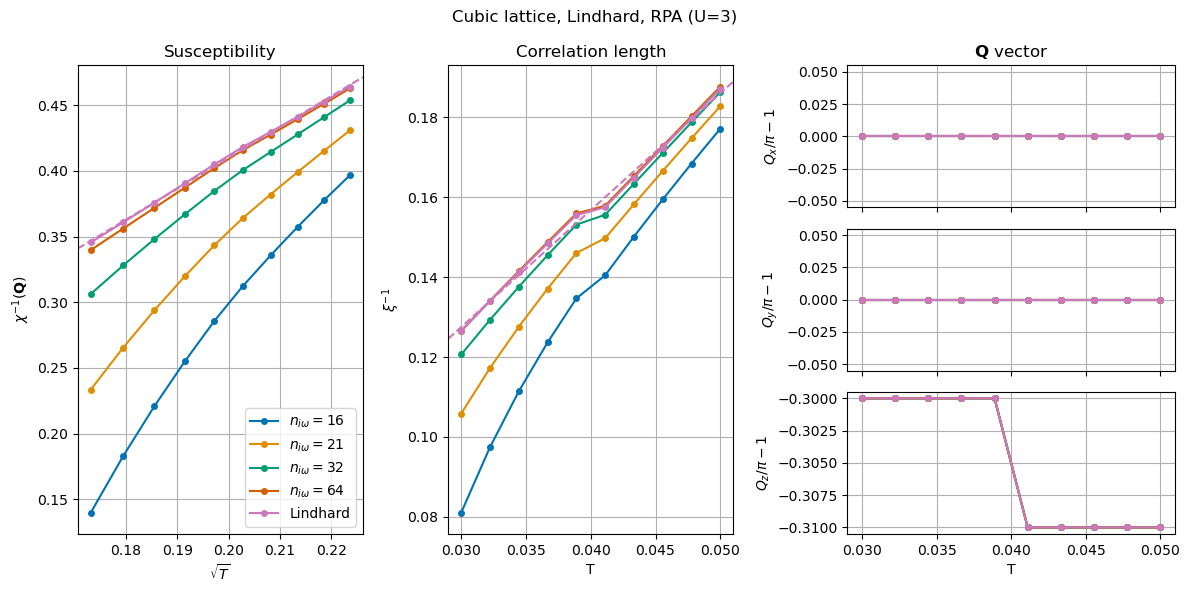

In [9]:
U = 3
n = 0.75
T_list = np.linspace(0.03, 0.05, 10)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE()
initialize_bz(lat, nk=200, refine=False, ibz=True)
par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]

niw_list = [64//i for i in range(1,5)][::-1]
results_list = []
for niw in niw_list:
    results_list.append(sweep_rpa(par_list, lat, niw=niw, get_xi=True, workers=5, xi_range=[0,0,5e-2]))

results_lindh = sweep_rpa(par_list, lat, q_path=([1,1,0], [1,1,1]), method='lindhard', get_xi=True, workers=5, xi_range=[0,0,5e-2])

fig = None
for results in results_list:
    niw = results['niw']
    fig, _ = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(0.5,1), fit=False, title=title, label=rf'$n_{{i\omega}} = {niw}$', figure=fig)
    
fig, fit = pcut_chi(results_lindh, 'T', plot_Q=(1,1,1), x_exp=(0.5,1), fit=True, title=title, label='Lindhard', figure=fig)

plt.show()

Starting serial run at: 2026-06-07 20:10:00.805074
Starting serial run at: 2026-06-07 20:10:00.875521
Starting serial run at: 2026-06-07 20:10:00.916871
Starting serial run at: 2026-06-07 20:10:00.954781


Starting serial run at: 2026-06-07 20:10:01.055054


7
7
7
7
7
7
7
7
7
7
n: 0.750, U: 3.000: Completed 10 jobs in 6.3 seconds
7
7
7
7
7
7
7
7
7
7
n: 0.750, U: 3.000: Completed 10 jobs in 5.2 seconds
7
7
7
7
7
7
7
7
7
7
n: 0.750, U: 3.000: Completed 10 jobs in 7.8 seconds
7
7
7
7
7
7
7
7
7
7
n: 0.750, U: 3.000: Completed 10 jobs in 15.4 seconds
n: 0.750, U: 3.000: Completed 10 jobs in 10.3 seconds


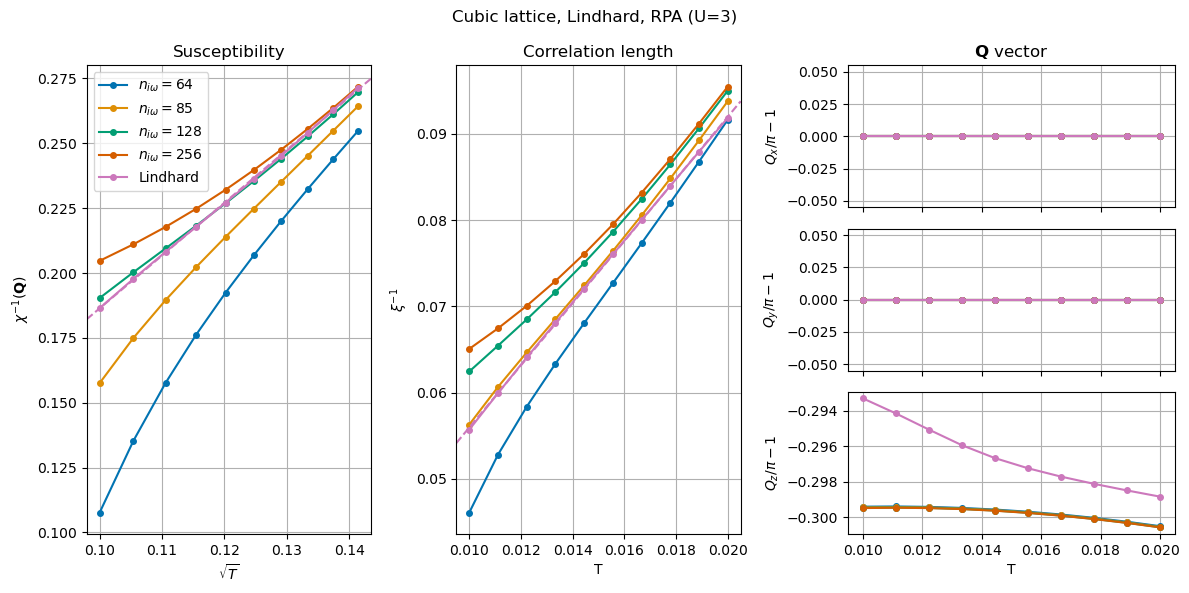

In [10]:
U = 3
n = 0.75
T_list = np.linspace(0.01, 0.02, 10)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE()
initialize_bz(lat, nk=100, refine=True, ibz=True)
par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]

niw_list = [256//i for i in range(1,5)][::-1]
results_list = []
for niw in niw_list:
    results_list.append(sweep_rpa(par_list, lat, niw=niw, get_xi=True, workers=5, xi_range=[0,0,5e-2]))

lat = LATTICE()
initialize_bz(lat, nk=50, refine=True, refine_ratio=2, ibz=True)
results_lindh = sweep_rpa(par_list, lat, q_path=([1,1,0], [1,1,1]), method='lindhard', get_xi=True, workers=5, xi_range=[0,0,5e-2])

fig = None
for results in results_list:
    niw = results['niw']
    fig, _ = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(0.5,1), fit=False, title=title, label=rf'$n_{{i\omega}} = {niw}$', figure=fig)
    
fig, fit = pcut_chi(results_lindh, 'T', plot_Q=(1,1,1), x_exp=(0.5,1), fit=True, title=title, label='Lindhard', figure=fig)

plt.show()

Starting serial run at: 2026-06-06 03:17:41.037135
Starting serial run at: 2026-06-06 03:17:41.047875
Starting serial run at: 2026-06-06 03:17:41.098987
Starting serial run at: 2026-06-06 03:17:41.175630
Starting serial run at: 2026-06-06 03:17:41.195526


U: 3.000, n: 0.750: Completed 15 jobs in 305.3 seconds
U: 3.000, n: 0.750: Completed 15 jobs in 616.7 seconds
U: 3.000, n: 0.750: Completed 15 jobs in 381.0 seconds
U: 3.000, n: 0.750: Completed 15 jobs in 634.1 seconds
U: 3.000, n: 0.750: Completed 15 jobs in 502.5 seconds
U: 3.000, n: 0.750: Completed 15 jobs in 449.2 seconds


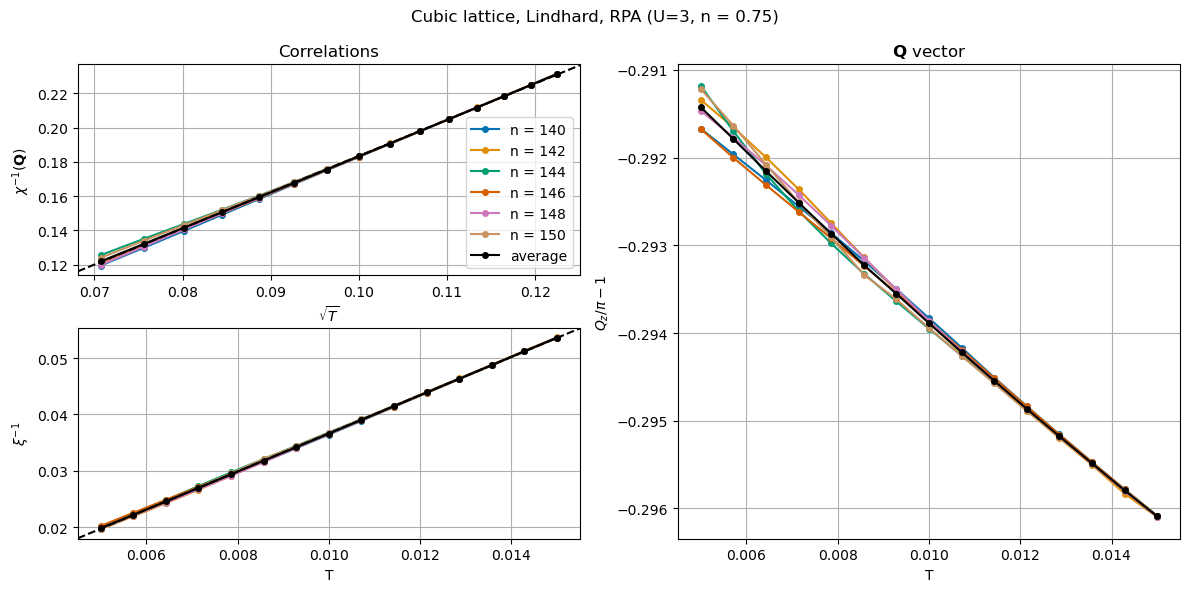

In [ ]:
U = 3
n = 0.75
T_list = np.linspace(0.005, 0.015, 15)
title = f'Cubic lattice, Lindhard, RPA (U={U}, n = {n})'

nk_list = np.arange(140, 151, 2)
par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]

results_list = []
for nk in nk_list:
    results_list.append(sweep_rpa(par_list, nk=nk, refine_ratio=2, q_path=([1,1,0], [1,1,1]), method='lindhard', get_xi=True, fit=True, workers=5))

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(0.5,1),
                        title=title, label=f'n = {nk}', figure=fig)

results_avg = results_list[-1].copy()
results_avg['invchi'] = sum([results['invchi'] for results in results_list])/len(results_list)
results_avg['invxi'] = sum([results['invxi'] for results in results_list])/len(results_list)
results_avg['Q'] = sum([results['Q'] for results in results_list])/len(results_list)

fig, fit = pcut_chi(results_avg, 'T', plot_Q=(0,0,1), x_exp=(0.5,1), fit=True,
                    title=title, label='average', figure=fig, color='black')

plt.show()

U: 3.000, n: 0.740: Completed 15 jobs in 1062.3 seconds
U: 3.000, n: 0.742: Completed 15 jobs in 1062.4 seconds
U: 3.000, n: 0.745: Completed 15 jobs in 1071.2 seconds
U: 3.000, n: 0.748: Completed 15 jobs in 1045.4 seconds
U: 3.000, n: 0.750: Completed 15 jobs in 1053.2 seconds
n = 0.74 :
 chi: gamma = 0.556, Tc = -0.003, xi: nu = 1.037, Tc = -0.009
n = 0.7424999999999999 :
 chi: gamma = 0.562, Tc = -0.002, xi: nu = 1.043, Tc = -0.008
n = 0.745 :
 chi: gamma = 0.509, Tc = 0.000, xi: nu = 1.027, Tc = -0.006
n = 0.7475 :
 chi: gamma = 0.543, Tc = 0.000, xi: nu = 1.019, Tc = -0.005
n = 0.75 :
 chi: gamma = 0.578, Tc = -0.000, xi: nu = 1.038, Tc = -0.005


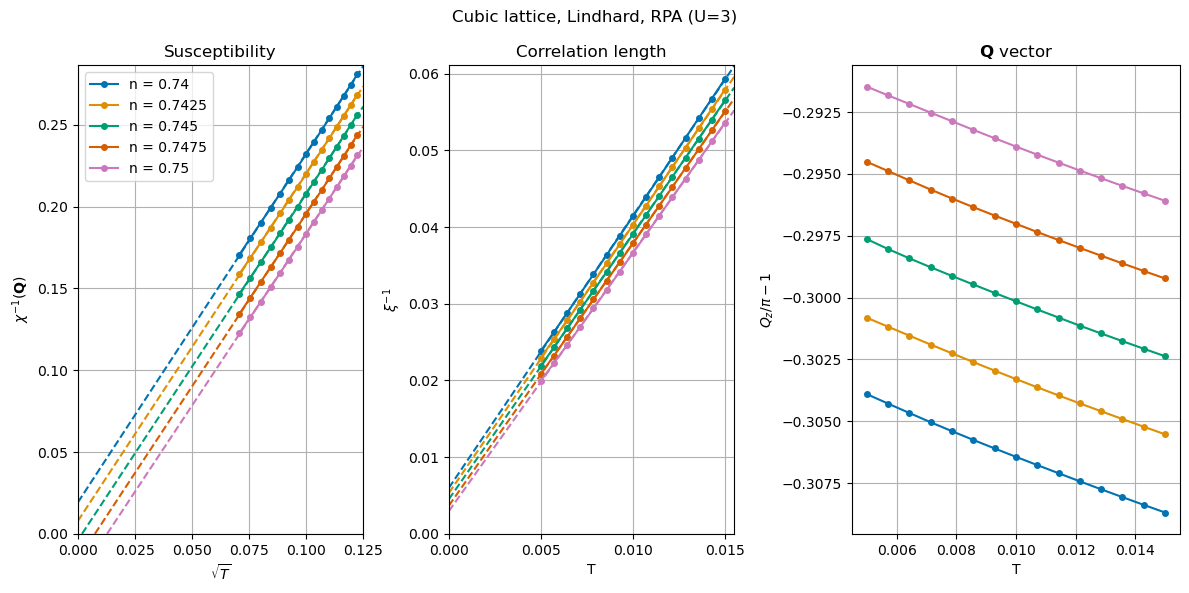

In [34]:
U = 3
n_list = np.linspace(0.74, 0.75, 5)
T_list = np.linspace(0.005, 0.015, 15)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE()
initialize_bz(lat, nk=200, refine=True, ibz=True, refine_ratio=2)

results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0], [1,1,1]), method='lindhard', get_xi=True, fit=True, workers=5))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(0.5,1), fit=True,
                        title=title, label=f'n = {n:4g}', figure=fig)
    
    _, axs = fig
    for ax in axs[:2]:
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

plt.show()

Starting serial run at: 2026-06-06 21:26:50.524014
Starting serial run at: 2026-06-06 21:26:50.529677
Starting serial run at: 2026-06-06 21:26:50.530041
Starting serial run at: 2026-06-06 21:26:50.548214
Starting serial run at: 2026-06-06 21:26:50.587727


n: 0.760, U: 3.000: Completed 15 jobs in 1050.3 seconds
n: 0.762, U: 3.000: Completed 15 jobs in 1009.8 seconds
n: 0.765, U: 3.000: Completed 15 jobs in 995.3 seconds
n: 0.768, U: 3.000: Completed 15 jobs in 1013.1 seconds
n: 0.770, U: 3.000: Completed 15 jobs in 1011.6 seconds
n = 0.76 :
 chi: gamma = 0.723, Tc = -0.021, xi: nu = 1.081, Tc = -0.023
n = 0.7625 :
 chi: gamma = 0.723, Tc = -0.015, xi: nu = 1.065, Tc = -0.020
n = 0.765 :
 chi: gamma = 0.727, Tc = -0.011, xi: nu = 1.050, Tc = -0.017
n = 0.7675000000000001 :
 chi: gamma = 0.729, Tc = -0.007, xi: nu = 1.031, Tc = -0.013
n = 0.77 :
 chi: gamma = 0.730, Tc = -0.003, xi: nu = 1.003, Tc = -0.009


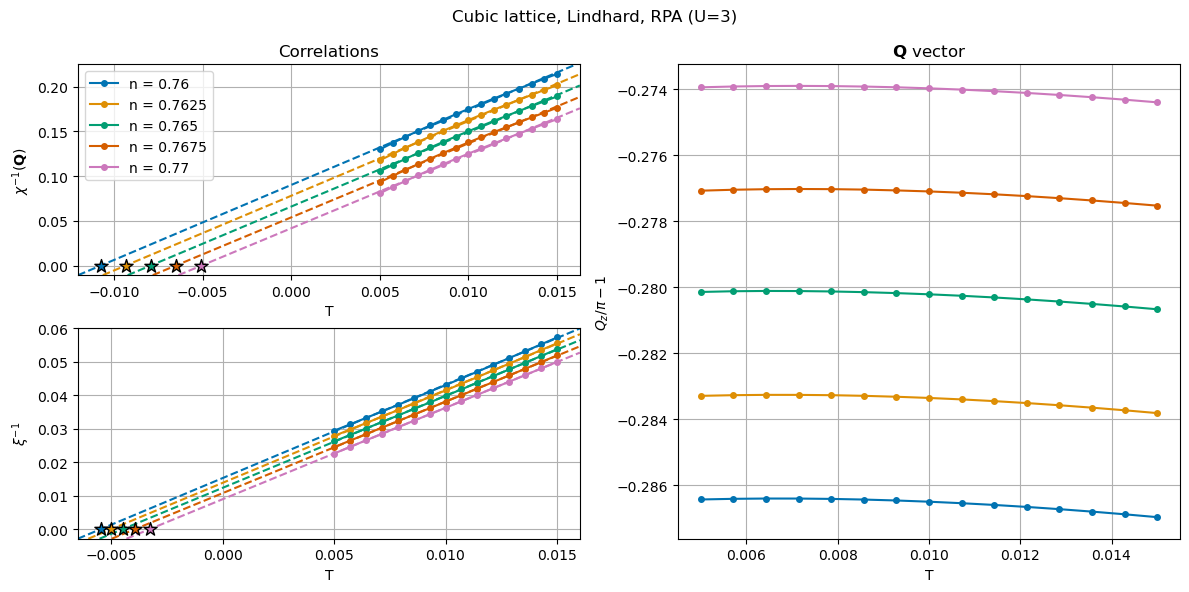

In [3]:
U = 3
n_list = np.linspace(0.76, 0.77, 5)
T_list = np.linspace(0.005, 0.015, 15)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE(tp=0.02)
initialize_bz(lat, nk=200, refine=True, ibz=True, refine_ratio=2)

results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0], [1,1,1]), method='lindhard', get_xi=True, fit=True, workers=5))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)

plt.show()

n = 0.76 :
 chi: gamma = 0.723, Tc = -0.021, xi: nu = 1.081, Tc = -0.023
n = 0.7625 :
 chi: gamma = 0.723, Tc = -0.015, xi: nu = 1.065, Tc = -0.020
n = 0.765 :
 chi: gamma = 0.727, Tc = -0.011, xi: nu = 1.050, Tc = -0.017
n = 0.7675000000000001 :
 chi: gamma = 0.729, Tc = -0.007, xi: nu = 1.031, Tc = -0.013
n = 0.77 :
 chi: gamma = 0.730, Tc = -0.003, xi: nu = 1.003, Tc = -0.009


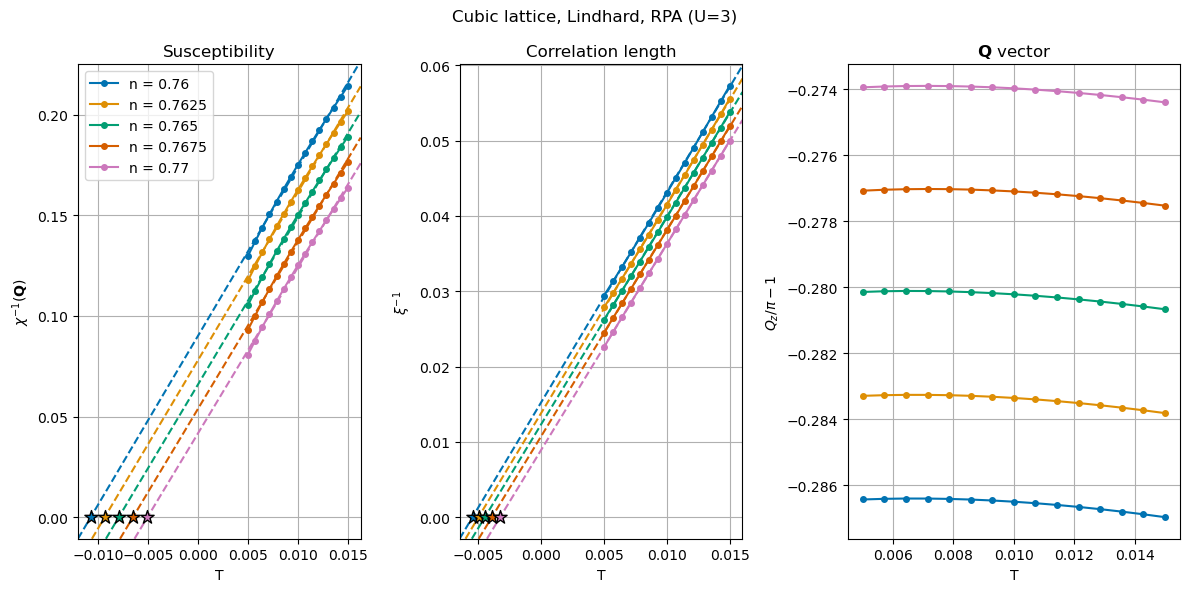

In [10]:
fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)

plt.show()

U: 3.000, n: 0.760: Completed 30 jobs in 713.2 seconds
U: 3.000, n: 0.762: Completed 30 jobs in 776.5 seconds
U: 3.000, n: 0.765: Completed 30 jobs in 727.3 seconds
U: 3.000, n: 0.768: Completed 30 jobs in 707.5 seconds
U: 3.000, n: 0.770: Completed 30 jobs in 716.3 seconds
n = 0.76 :
 chi: gamma = 0.680, Tc = 0.000, xi: nu = 0.989, Tc = -0.006
n = 0.7625 :
 chi: gamma = 0.702, Tc = 0.001, xi: nu = 0.961, Tc = -0.004
n = 0.765 :
 chi: gamma = 0.729, Tc = 0.004, xi: nu = 0.897, Tc = -0.000
n = 0.7675000000000001 :
 chi: gamma = 0.727, Tc = 0.008, xi: nu = 0.837, Tc = 0.001
n = 0.77 :
 chi: gamma = 0.715, Tc = 0.012, xi: nu = 0.745, Tc = 0.002


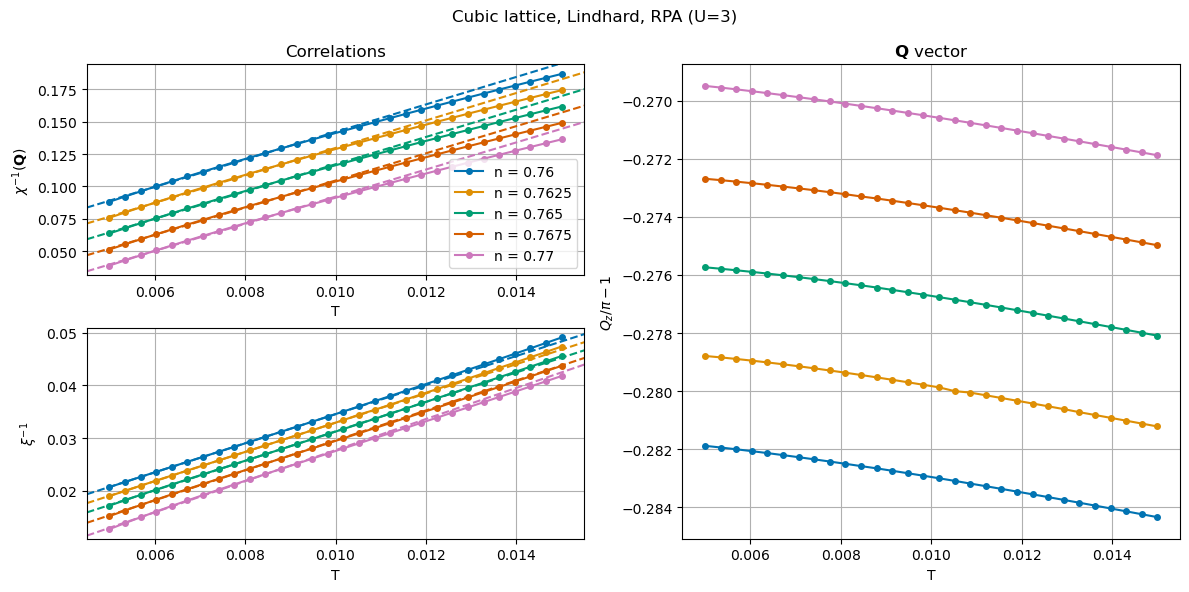

In [6]:
U = 3
n_list = np.linspace(0.76, 0.77, 5)
T_list = np.linspace(0.005, 0.015, 30)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE(tp=0.01)
initialize_bz(lat, nk=150, refine=True, ibz=True, refine_ratio=2)

results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0], [1,1,1]), method='lindhard', get_xi=True, fit=True, workers=5))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    #_, axs = fig
    #color = axs[0].lines[-1].get_color()
    #axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)

plt.show()

U: 3.000, n: 0.886: Completed 15 jobs in 518.2 seconds
U: 3.000, n: 0.887: Completed 15 jobs in 522.7 seconds
U: 3.000, n: 0.887: Completed 15 jobs in 491.8 seconds
U: 3.000, n: 0.887: Completed 15 jobs in 471.0 seconds
U: 3.000, n: 0.887: Completed 15 jobs in 470.8 seconds
U: 3.000, n: 0.887: Completed 15 jobs in 454.5 seconds
n = 0.8865 :
 chi: gamma = 1.014, Tc = -0.007, xi: nu = 1.363, Tc = -0.041
n = 0.8866999999999999 :
 chi: gamma = 0.968, Tc = -0.004, xi: nu = 1.325, Tc = -0.032
n = 0.8868999999999999 :
 chi: gamma = 0.379, Tc = 0.000, xi: nu = 0.466, Tc = 0.000
n = 0.8871 :
 chi: gamma = 1.502, Tc = -0.033, xi: nu = 0.766, Tc = -0.000
n = 0.8873 :
 chi: gamma = 2.170, Tc = -0.081, xi: nu = 1.595, Tc = -0.063
n = 0.8875 :
 chi: gamma = 1.672, Tc = -0.003, xi: nu = 1.830, Tc = -0.068


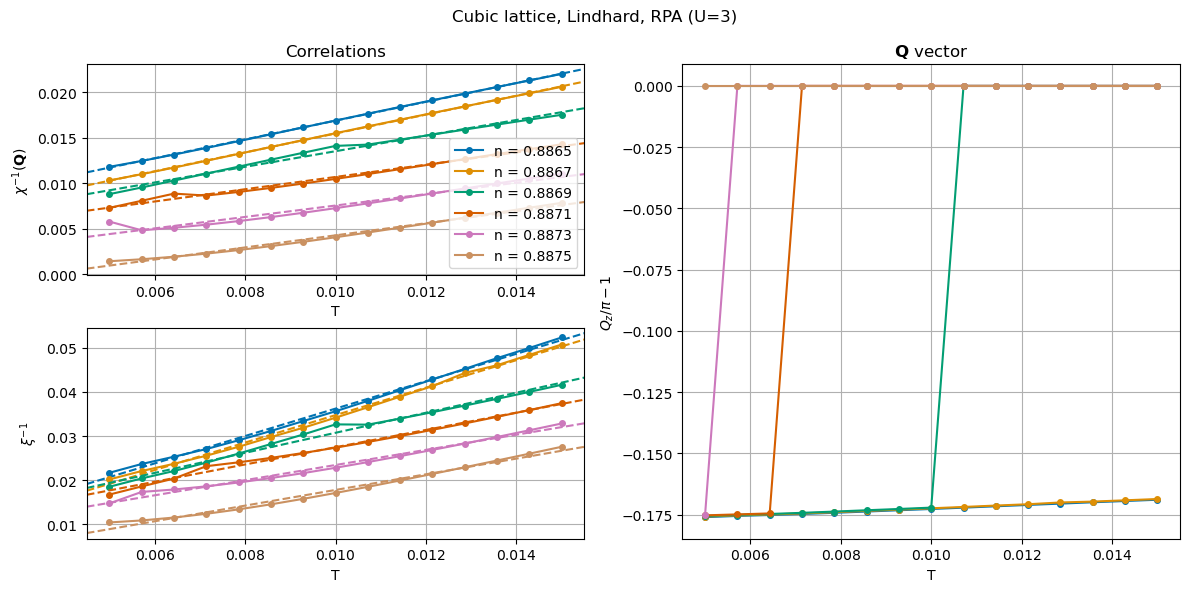

In [7]:
U = 3
n_list = np.linspace(0.8865, 0.8875, 6)
T_list = np.linspace(0.005, 0.015, 15)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE(tp=0.172)
initialize_bz(lat, nk=200, refine=True, ibz=True, refine_ratio=3/2)

niw = 256
results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, niw=niw, get_xi=True, fit=True, workers=5))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    #_, axs = fig
    #color = axs[0].lines[-1].get_color()
    #axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)

plt.show()

U: 3.000, n: 0.845: Completed 15 jobs in 1147.1 seconds
U: 3.000, n: 0.846: Completed 15 jobs in 1144.4 seconds
U: 3.000, n: 0.847: Completed 15 jobs in 1142.5 seconds
U: 3.000, n: 0.848: Completed 15 jobs in 1111.7 seconds
U: 3.000, n: 0.849: Completed 15 jobs in 1115.6 seconds
U: 3.000, n: 0.850: Completed 15 jobs in 1114.5 seconds
n = 0.845 :
 chi: gamma = 1.010, Tc = -0.020, xi: nu = 1.128, Tc = -0.023
n = 0.846 :
 chi: gamma = 1.013, Tc = -0.014, xi: nu = 1.105, Tc = -0.018
n = 0.847 :
 chi: gamma = 1.005, Tc = -0.008, xi: nu = 1.087, Tc = -0.012
n = 0.848 :
 chi: gamma = 0.994, Tc = -0.001, xi: nu = 1.031, Tc = -0.005
n = 0.849 :
 chi: gamma = 0.989, Tc = 0.004, xi: nu = 0.947, Tc = 0.001
n = 0.85 :
 chi: gamma = 0.992, Tc = 0.010, xi: nu = 0.790, Tc = 0.004


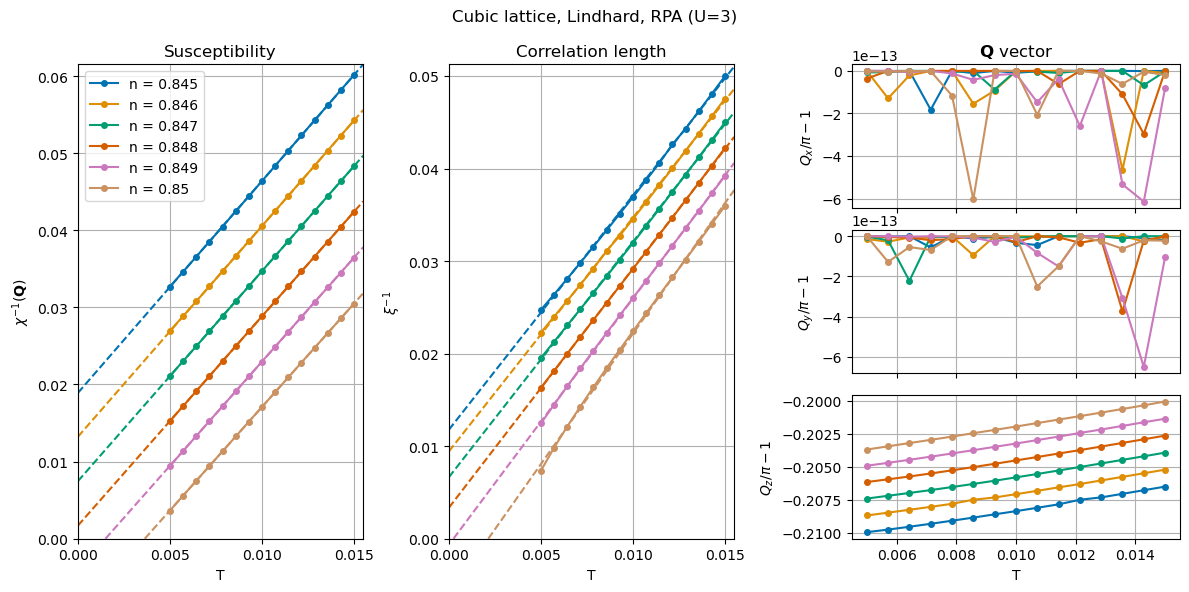

In [35]:
U = 3
n_list = np.linspace(0.845, 0.85, 6)
T_list = np.linspace(0.005, 0.015, 15)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE(tp=0.1)
initialize_bz(lat, nk=200, refine=True, ibz=True, refine_ratio=2)

niw = 256
results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, niw=niw, get_xi=True, fit=True, workers=5))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    _, axs = fig
    for ax in axs[:2]:
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

plt.show()

U: 3.000, n: 0.885: Completed 15 jobs in 952.3 seconds
U: 3.000, n: 0.885: Completed 15 jobs in 953.8 seconds
U: 3.000, n: 0.885: Completed 15 jobs in 952.4 seconds
U: 3.000, n: 0.885: Completed 15 jobs in 951.7 seconds
U: 3.000, n: 0.885: Completed 15 jobs in 947.9 seconds
Fit of invxi values did not converge
U: 3.000, n: 0.885: Completed 15 jobs in 757.4 seconds
n = 0.8848 :
 chi: gamma = 2.024, Tc = -0.041, xi: nu = 1.475, Tc = -0.071
n = 0.8848400000000001 :
 chi: gamma = 2.019, Tc = -0.034, xi: nu = 1.384, Tc = -0.052
n = 0.88488 :
 chi: gamma = 2.015, Tc = -0.026, xi: nu = 1.237, Tc = -0.028
n = 0.88492 :
 chi: gamma = 2.010, Tc = -0.014, xi: nu = 0.940, Tc = -0.002
n = 0.88496 :
 chi: gamma = 2.057, Tc = 0.018, xi: nu = 0.079, Tc = 0.000
n = 0.885 :
 chi: gamma = 2.226, Tc = 0.036, xi: nu = nan, Tc = nan


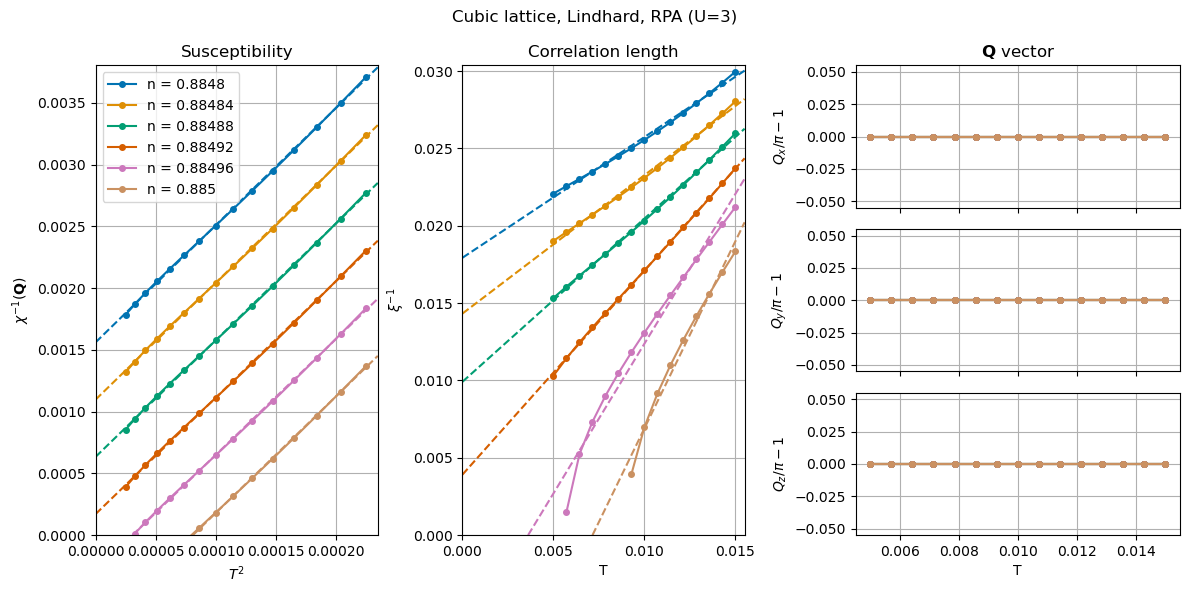

In [36]:
U = 3
n_list = np.linspace(0.8848, 0.885, 6)
T_list = np.linspace(0.005, 0.015, 15)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE(tp=0.2)
initialize_bz(lat, nk=200, refine=True, ibz=True, refine_ratio=2)

niw = 256
results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, niw=niw, get_xi=True, fit=True, workers=5))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(2,1), fit=True, title=title, label=f'n = {n:.5g}', figure=fig)
    
    _, axs = fig
    for ax in axs[:2]:
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.05, 15)

nk = 82
file = f'{save_dir}/nTdiag_U3'
if os.path.exists(file):
    results = HDFread_list(file, ['Xc'])
    n_old = [par_list[0]['n'] for par_list in results['par_list']]
    Tc_old = [x[0] for x in results['Xc']]
    Tc = np.interp(n_list, n_old, Tc_old)
else:
    print(f'file {file} does not exist!')

par_list = []
for i, n in enumerate(n_list):
    par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'lindhard', 'q_path': ([1,1,0], [1,1,1]),
               'fit': True, 'fit_type': [critical1, critical2], 'refine_ratio': 2} for par_dict in par_list]
results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.7, 1)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.4)
ax[1].set_ylim(0., 2.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_z/\pi-1$')

results = HDFread_list(f'{save_dir}/nTdiag_U3', ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
n_fits = len(results['Xc'][0])

for i in range(n_fits):
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[i][-1]-1 for Q in results['Qc']]
    Xc = [x[i] for x in results['Xc']]
    Xc_err = [x[i] for x in results['Xc_err']]
    gamma = [x[i] for x in results['gamma']]
    gamma_err = [x[i] for x in results['gamma_err']]
    mu_c = [x[i] for x in results['mu_c']]
    print(mu_c)

    ax[0].errorbar(n_list, Xc, Xc_err, fmt='o-', label=f"fit type {i+1}", markersize=4)
    ax[1].errorbar(n_list, gamma, gamma_err, fmt='o-', label=f"fit type {i+1}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"fit type {i+1}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., Xc, n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

plt.savefig(f'{save_dir}/fit_type.png', dpi=100)
plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.73, 0.91, 24)
T_list = np.linspace(0., 0.05, 15)

nk = 80
niw = 256
tp_list = [0., 0.05, 0.1]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'niw': niw, 'niw_extr': True, 'refine': True, 'refine_ratio': 2} for par_dict in par_list]
    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 
    #               'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
    sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.73, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.2)
ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0., 0.05, 0.1]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qj = [[Q[j]-1 for Q in results['Qc']] for j in range(3)]
    print(len(n_list), n_list)
    n_list.pop(-4)
    print(len(n_list), n_list)
    results['Xc'].pop(-4)
    results['Xc_err'].pop(-4)
    results['gamma'].pop(-4)
    results['gamma_err'].pop(-4)
    results['mu_c'].pop(-4)

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for j, a in enumerate(ax[2:]):
        Qj[j].pop(-4)
        a.plot(n_list, Qj[j], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    n_crit2 = np.interp(0., results['mu_c'], n_list)
    #print(n_crit2, tp, results['mu_c'])
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.axvline(n_crit2, linestyle='-.', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.87, 0.91, 18)
T_list = np.linspace(0., 0.2, 20)

nk = 80
niw = 256
tp_list = [0.15, 0.2, 0.25]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'niw': niw, 'niw_extr': True, 'refine': True, 'refine_ratio': 2} for par_dict in par_list]
    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 
    #               'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1]), 'refine_ratio': 2} for par_dict in par_list]
    sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.87, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.3)
#ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0.15, 0.2, 0.25]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qj = [[Q[j]-1 for Q in results['Qc']] for j in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for j, a in enumerate(ax[2:]):
        a.plot(n_list, Qj[j], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    n_crit2 = np.interp(0., results['mu_c'], n_list)
    print(n_crit2, tp, results['mu_c'])
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.axvline(n_crit2, linestyle='-.', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.73, 0.91, 12)
T_list = np.linspace(0., 0.04, 15)

nk = 50
niw = 128
tp_list = [-0.05, -0.1, -0.15, -0.2]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'niw': niw, 'niw_extr': True, 'refine': False} for #par_dict in par_list]
    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 
                   'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    #Tc = np.array([res['Xc'] for res in results])
    #i_crit = np.argwhere(Tc > 0)[0,0]
    #n_list = n_list[max(i_crit-2,0):]

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.72, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.2)
ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0., -0.05, -0.1, -0.15, -0.2]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qj = [[Q[j]-1 for Q in results['Qc']] for j in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for j, a in enumerate(ax[2:]):
        a.plot(n_list, Qj[j], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    n_crit2 = np.interp(-tp, results['mu_c'], n_list)
    print(tp, results['mu_c'])
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.axvline(n_crit2, linestyle='-.', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/negtp.png', dpi=100)
plt.show()

In [ ]:
save_dir = f'data/{dim}d/rpa_ba'

In [ ]:
U = 3
n_list = np.linspace(0.73, 0.91, 12)
T_list = np.linspace(0., 0.04, 15)

nk = 100
niw = 128
Gamma_list = [0.01, 0.025, 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'S_iwk_list': -1.j*Gamma, 'niw': niw, 'niw_extr': True, 'refine': False} for par_dict in par_list]
    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'S_iwk_list': -1.j*Gamma,
    #               'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    #Tc = np.array([res['Xc'] for res in results])
    #i_crit = np.argwhere(Tc > 0)[0,0]
    #n_list = n_list[max(i_crit-2,0):]

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.72, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.2)
ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

Gamma_list = [0., 0.01, 0.025, 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qi = [[Q[i]-1 for Q in results['Qc']] for i in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=rf"$\Gamma={Gamma}$", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=rf"$\Gamma={Gamma}$", markersize=4)
    for i, a in enumerate(ax[2:]):
        a.plot(n_list, Qi[i], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()

In [ ]:
import tracemalloc

tracemalloc.start()
lattice = LATTICE()
nk = 300
lattice.get_k_mesh(nk, ibz=True)
lattice.get_e_k()
print(len(lattice.e_k),'/',nk**3, lattice.e_k)
print(lattice.ibz_w_k.sum())

current, peak = tracemalloc.get_traced_memory()
print(f"peak during fourier: {peak / 1e6:.1f} MB")
tracemalloc.stop()